# Dimensionality Expansion

Visualise the distribution of $x_{hd}$ components before and after sensor trace
expansion. For a given $(p, d)$:

1. **Raw sensor traces** (8 channels)
   - Histograms of z-scored $x_{hd}$ for 5 random samples
   - Bivariate heatmaps + correlation for 5 random pairs

2. **Expanded to 136 traces** ($\partial^{1-2}$ + 56R + 56D)
   - Same histogram and heatmap diagnostics

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from tools import load
from math import comb
import torch


def backward_diff_array(y, h, n):
    """n-th backward finite difference (zero-padded to preserve length)."""
    coeffs = np.array([(-1)**k * comb(n, k) for k in range(n + 1)])
    raw = np.convolve(y, coeffs, mode='valid') / h**n
    return np.concatenate([np.zeros(n), raw])


device = torch.device('mps' if torch.backends.mps.is_available() else
                       'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [3]:
filename = '1_600_20'
sensor_data, sequence, times_sec, sequence_sec = load(filename, reduced=True)
h = np.median(np.diff(times_sec))
n_sensors = sensor_data.shape[1]

# Labels
labels = np.zeros_like(times_sec)
for i in range(len(sequence_sec)):
    try:
        flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i + 1])
    except IndexError:
        flag = (times_sec > sequence_sec[i])
    labels[flag] = int(sequence[i][1])

labeled_mask = labels > 0
n_samples = sensor_data.shape[0]

print(f"Sensor data: {sensor_data.shape}  ({n_sensors} sensors)")
print(f"Labeled samples: {np.sum(labeled_mask)}")

Sensor data: (11691, 8)  (8 sensors)
Labeled samples: 11392


In [4]:
# Expansion helpers
def expand_with_derivatives(data, h, max_order):
    if max_order == 0:
        return data.copy()
    derivs = []
    for order in range(1, max_order + 1):
        d = np.apply_along_axis(
            lambda col: backward_diff_array(col, h, order), axis=0, arr=data)
        derivs.append(d)
    return np.hstack([data] + derivs)


# Pair pools
rng_pairs = np.random.default_rng(0)
all_ordered_pairs = [(i, j) for i in range(n_sensors) for j in range(n_sensors) if i != j]
ratio_pairs = [all_ordered_pairs[i] for i in rng_pairs.permutation(len(all_ordered_pairs))]
diff_pairs  = [all_ordered_pairs[i] for i in rng_pairs.permutation(len(all_ordered_pairs))]

# Raw (8 traces)
x_raw = sensor_data.copy()

# 136-trace expansion (d1 + d2 + 56R + 56D)
x_d12 = expand_with_derivatives(sensor_data, h, max_order=2)  # 24 cols
r56 = np.column_stack([sensor_data[:, i] / (sensor_data[:, j] + 1e-8) for i, j in ratio_pairs[:56]])
d56 = np.column_stack([sensor_data[:, i] - sensor_data[:, j] for i, j in diff_pairs[:56]])
x_136 = np.hstack([x_d12, r56, d56])

print(f"Raw:      {x_raw.shape}")
print(f"Expanded: {x_136.shape}")

Raw:      (11691, 8)
Expanded: (11691, 136)


In [5]:
# HD projection parameters
p = 0.2
d = 0.2
n_hd = 10_000
k = int(d * n_hd)

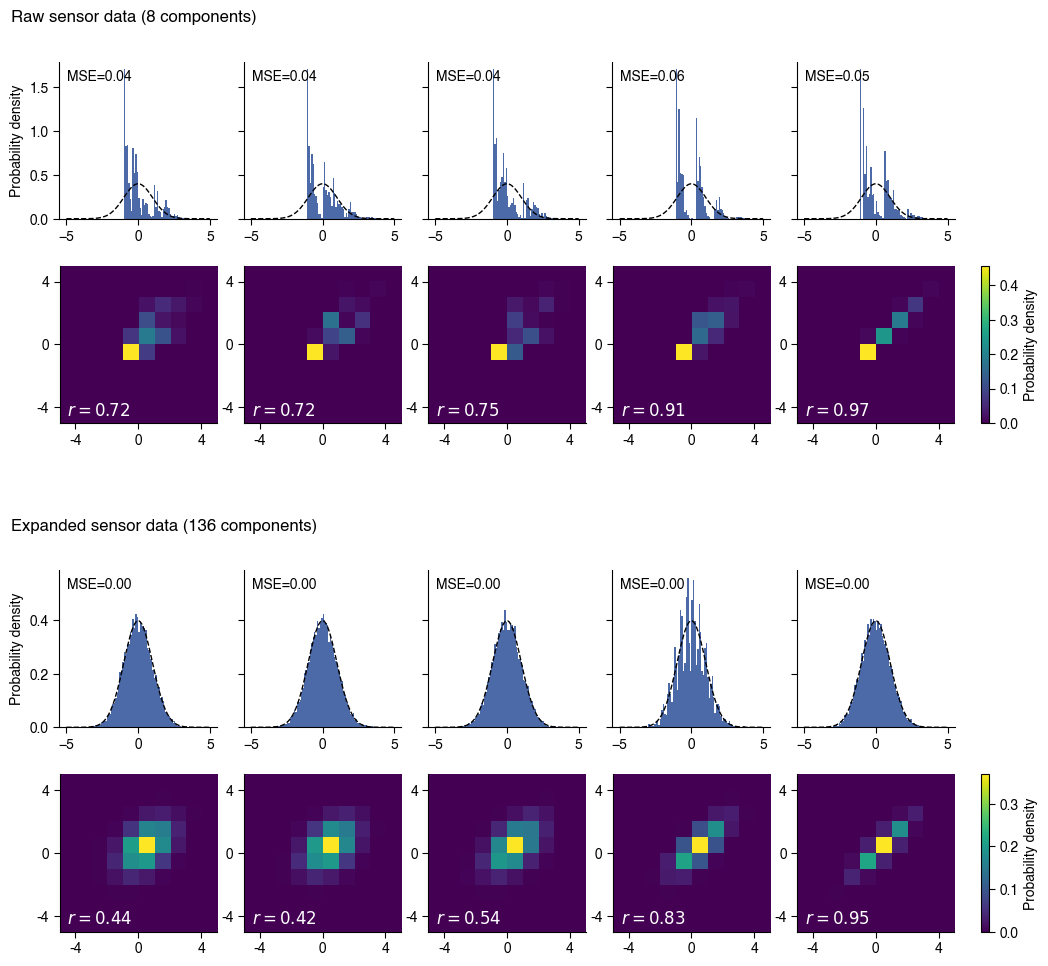

In [6]:
n_col = 5
res = 10
z_range = np.linspace(-5, 5, 100)
normal_pdf = norm.pdf(z_range)
box = np.linspace(-5, 5, res)
bin_width = 10.0 / res
cell_area = bin_width ** 2

# HD projections
n_dense_raw = x_raw.shape[1]
n_dense_exp = x_136.shape[1]

x_raw_t = torch.tensor(x_raw, dtype=torch.float32, device=device)
W_raw = torch.bernoulli(torch.full((n_hd, n_dense_raw), p, device=device))
x_hd_raw = x_raw_t @ W_raw.T

x_exp_t = torch.tensor(x_136, dtype=torch.float32, device=device)
W_exp = torch.bernoulli(torch.full((n_hd, n_dense_exp), p, device=device))
x_hd_exp = x_exp_t @ W_exp.T

# Random indices
hist_idx = np.random.randint(0, n_samples, size=n_col)
pair_indices = np.array([np.random.choice(n_samples, size=2, replace=False) for _ in range(n_col)])

fig, axes = plt.subplots(4, n_col + 1, figsize=(12, 10),
                         gridspec_kw={'hspace': 0.3, 'width_ratios': [1]*n_col + [0.05]})

fig.subplots_adjust(hspace=0.3)

for x_hd_cur, label, row_hist, row_hmap in [
    (x_hd_raw, f'Raw ({n_dense_raw} ch)', 0, 1),
    (x_hd_exp, f'Expanded ({n_dense_exp} ch)', 2, 3),
]:
    # --- histograms ---
    vals = x_hd_cur[hist_idx, :].cpu().numpy()
    for j in range(n_col):
        ax = axes[row_hist, j]
        if j > 0:
            ax.sharey(axes[row_hist, 0])
        mean = np.mean(vals[j, :])
        std = np.std(vals[j, :])
        if std == 0:
            std = 1e-6
        values_recast = (vals[j, :] - mean) / std
        counts, bin_edges, _ = ax.hist(values_recast, bins=100, range=(-5, 5), density=True, color='C0')
        ax.plot(z_range, normal_pdf, '--', color='black', linewidth=1.)

        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        pdf_at_centers = norm.pdf(bin_centers)
        mse = np.mean((counts - pdf_at_centers)**2)
        ax.text(0.05, 0.95, f'MSE={mse:.2f}', transform=ax.transAxes,
                ha='left', va='top', fontsize=10)
        if j == 0:
            ax.set_ylabel('Probability density', fontsize=10)
        else:
            ax.tick_params(labelleft=False)

    # Hide the 6th column for histogram rows
    axes[row_hist, n_col].set_visible(False)

    # --- heatmaps ---
    ims = []
    for j in range(n_col):
        ax = axes[row_hmap, j]
        idx1 = pair_indices[j][0]
        idx2 = pair_indices[j][1]
        x_hd1 = x_hd_cur[idx1].cpu().numpy()
        x_hd2 = x_hd_cur[idx2].cpu().numpy()
        mean1, std1 = np.mean(x_hd1), np.std(x_hd1)
        mean2, std2 = np.mean(x_hd2), np.std(x_hd2)
        if std1 == 0:
            std1 = 1e-6
        if std2 == 0:
            std2 = 1e-6
        v1 = (x_hd1 - mean1) / std1
        v2 = (x_hd2 - mean2) / std2
        corr = np.corrcoef(v1, v2)[0, 1]
        hmap = np.zeros((res, res))
        for m in range(n_hd):
            x1 = (v1[m] < box) & (v1[m] >= box - 10./res)
            x2 = (v2[m] < box) & (v2[m] >= box - 10./res)
            hmap[x1, x2] += 1

        # Normalize: hmap * cell_area sums to 1
        total = hmap.sum()
        if total > 0:
            hmap = hmap / (total * cell_area)

        im = ax.imshow(hmap, origin='lower')
        ims.append(im)
        ax.set_xticks([res/10 - 0.5, res/2 - 0.5, 9*res/10 - 0.5], labels=[-4, 0, 4])
        ax.set_yticks([res/10 - 0.5, res/2 - 0.5, 9*res/10 - 0.5], labels=[-4, 0, 4])
        ax.text(0.05, 0.05, f'$r={corr:.2f}$', transform=ax.transAxes, color='white')

    # Colorbar in the 6th column
    fig.colorbar(ims[-1], cax=axes[row_hmap, n_col], label='Probability density')

# Increase separation between row 1 and row 2 by shifting rows 2-3 down
fig.canvas.draw()
for row in [2, 3]:
    for col in range(n_col + 1):
        pos = axes[row, col].get_position()
        axes[row, col].set_position([pos.x0, pos.y0 - 0.1, pos.width, pos.height])

left_offset = 0.04
top_offset = 0.04
x_left = axes[0, 0].get_position().x0
fig.text(x_left - left_offset, axes[0, 0].get_position().y1 + top_offset, 'Raw sensor data (8 components)', transform=fig.transFigure)
fig.text(x_left - left_offset, axes[2, 0].get_position().y1 + top_offset, 'Expanded sensor data (136 components)', transform=fig.transFigure)

plt.show()

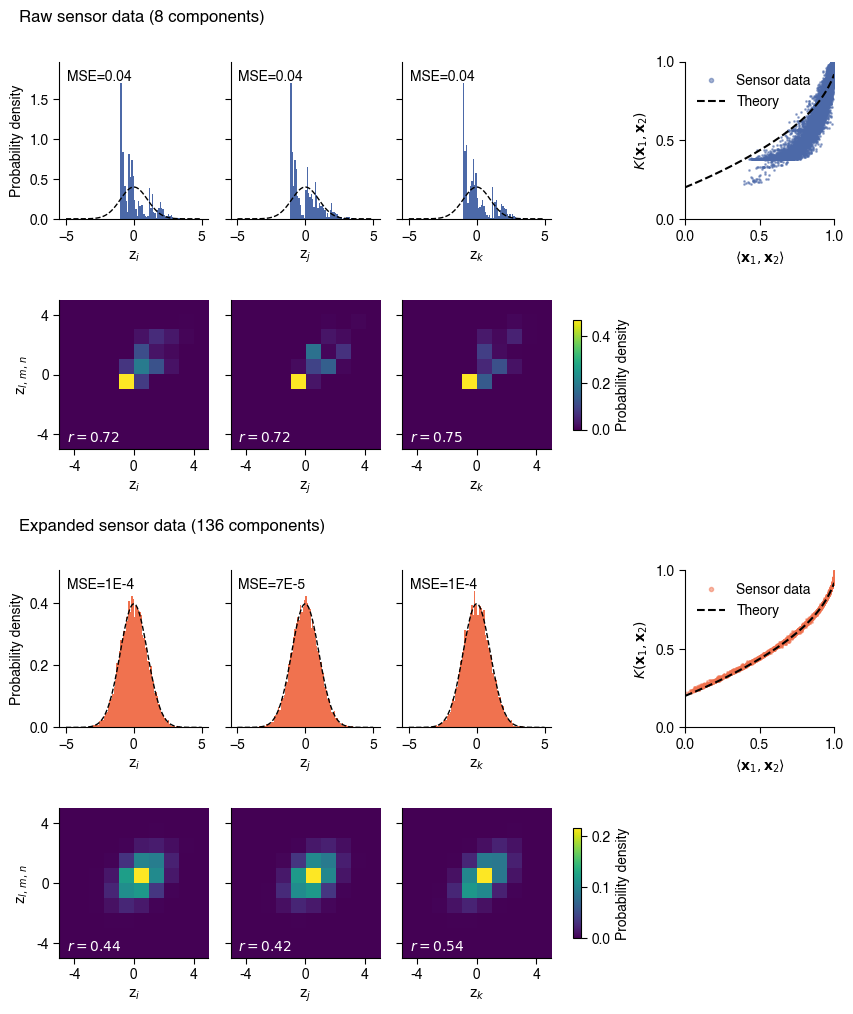

In [17]:
from math import sqrt, pi, exp as math_exp, floor, log10

# --- Kernel function (cf. Kernel shape notebook, cell 5) ---
def _phi_k(x):
    return (1.0 / sqrt(2.0 * pi)) * math_exp(-0.5 * x * x)

def K(r, s, n_terms=30):
    r = float(min(max(r, np.nextafter(-1.0, 0.0)), np.nextafter(1.0, 0.0)))
    d_val = 1.0 - s
    t = float(norm.ppf(s))
    phi_t = _phi_k(t)
    a_prev, a_curr = d_val, phi_t
    rn_nfact = 1.0
    result = rn_nfact * a_prev * a_prev
    for n in range(1, n_terms + 1):
        rn_nfact *= r / n
        result += rn_nfact * a_curr * a_curr
        a_prev, a_curr = a_curr, t * a_curr - (n - 1) * a_prev
    return result / d_val

def mse_sci(val):
    """Format as XE-Y with one significant digit, e.g. 0.0023 -> '2E-3'."""
    if val == 0:
        return '0'
    exp = int(floor(log10(abs(val))))
    coeff = round(val / 10**exp)
    return f'{coeff}E{exp}'

# --- Sparsify HD projections for kernel scatter ---
s_val = 1 - d

ranks_raw_s = torch.argsort(torch.argsort(-x_hd_raw, dim=1), dim=1)
z_hd_raw_bin = (ranks_raw_s < k).float().cpu().numpy()

ranks_exp_s = torch.argsort(torch.argsort(-x_hd_exp, dim=1), dim=1)
z_hd_exp_bin = (ranks_exp_s < k).float().cpu().numpy()

# Normalize dense vectors for cosine similarity
x_raw_norm = x_raw / (np.linalg.norm(x_raw, axis=1, keepdims=True) + 1e-8)
x_136_norm = x_136 / (np.linalg.norm(x_136, axis=1, keepdims=True) + 1e-8)

# Use labeled samples only
x_raw_n = x_raw_norm[labeled_mask]
x_136_n = x_136_norm[labeled_mask]
z_raw_n = z_hd_raw_bin[labeled_mask]
z_exp_n = z_hd_exp_bin[labeled_mask]

n_pairs_k = 10000
rng_k = np.random.default_rng(42)

def kernel_scatter_data(x_n, z_n, n_p, k_val):
    xs, ys = [], []
    for _ in range(n_p):
        i1, i2 = rng_k.choice(len(x_n), size=2, replace=False)
        xs.append(np.dot(x_n[i1], x_n[i2]))
        ys.append(np.dot(z_n[i1], z_n[i2]) / k_val)
    return np.array(xs), np.array(ys)

ks_raw_x, ks_raw_y = kernel_scatter_data(x_raw_n, z_raw_n, n_pairs_k, k)
ks_exp_x, ks_exp_y = kernel_scatter_data(x_136_n, z_exp_n, n_pairs_k, k)

rs_th = np.arange(0, 1.01, 0.01)
vals_th = [K(r=ri, s=s_val) for ri in rs_th]

# --- Figure: 4 rows x 6 cols ---
# Cols 0-2: data (3 instead of 5)
# Col 3:    colorbar (thin)
# Col 4:    empty spacer
# Col 5:    kernel scatter (rows 0 and 2 only)
n_data = 3
n_total_cols = 6  # 0-2 data, 3 cbar, 4 spacer, 5 kernel
cbar_shrink = 0.7  # fraction of row height for colorbar (1.0 = full height)
hist_xlabels = [r'$\text{z}_i$', r'$\text{z}_j$', r'$\text{z}_k$']
hmap_xlabels = [r'$\text{z}_i$', r'$\text{z}_j$', r'$\text{z}_k$']

# ── Spacing knobs (figure-fraction units) ──
# inter_gap : extra space between the two blocks (rows 1↔2)
# intra_gap : extra space between histogram and heatmap within each block (rows 0↔1, 2↔3)
inter_gap = 0.10   # ↑ increase to push the two blocks further apart
intra_gap = 0.03   # ↑ increase to push histograms and heatmaps apart inside a block

fig, axes = plt.subplots(4, n_total_cols, figsize=(10, 10),
                         gridspec_kw={'hspace': 0.3,
                                      'width_ratios': [1]*n_data + [0.05, 0.4, 1.]})
fig.subplots_adjust(hspace=0.3)

# Hide all spacer column axes (col 4)
for row in range(4):
    axes[row, 4].set_visible(False)

# Hide kernel column axes in rows 1 and 3
axes[1, 5].set_visible(False)
axes[3, 5].set_visible(False)

hist_idx_3 = hist_idx[:n_data]
pair_idx_3 = pair_indices[:n_data]

cbar_axes = []
for x_hd_cur, label, row_hist, row_hmap, hist_color in [
    (x_hd_raw, f'Raw ({n_dense_raw} ch)', 0, 1, 'C0'),
    (x_hd_exp, f'Expanded ({n_dense_exp} ch)', 2, 3, 'C1'),
]:
    # --- histograms (cols 0-2) ---
    vals = x_hd_cur[hist_idx_3].cpu().numpy()
    for j in range(n_data):
        ax = axes[row_hist, j]
        if j > 0:
            ax.sharey(axes[row_hist, 0])
        mn, sd = np.mean(vals[j]), np.std(vals[j])
        if sd == 0: sd = 1e-6
        vz = (vals[j] - mn) / sd
        counts, be, _ = ax.hist(vz, bins=100, range=(-5, 5),
                                density=True, color=hist_color)
        ax.plot(z_range, normal_pdf, '--', color='black', lw=1.)
        bc = 0.5 * (be[:-1] + be[1:])
        mse = np.mean((counts - norm.pdf(bc))**2)
        if row_hist == 2:
            mse_str = f'MSE={mse_sci(mse)}'
        else:
            mse_str = f'MSE={mse:.2f}'
        ax.text(0.05, 0.95, mse_str, transform=ax.transAxes,
                ha='left', va='top', fontsize=10)
        ax.set_xlabel(hist_xlabels[j], fontsize=10)
        if j == 0:
            ax.set_ylabel('Probability density', fontsize=10)
        else:
            ax.tick_params(labelleft=False)

    # Hide colorbar axis for histogram rows
    axes[row_hist, 3].set_visible(False)

    # --- heatmaps (cols 0-2) ---
    ims = []
    for j in range(n_data):
        ax = axes[row_hmap, j]
        i1, i2 = pair_idx_3[j]
        h1 = x_hd_cur[i1].cpu().numpy()
        h2 = x_hd_cur[i2].cpu().numpy()
        m1, s1 = np.mean(h1), np.std(h1)
        m2, s2 = np.mean(h2), np.std(h2)
        if s1 == 0: s1 = 1e-6
        if s2 == 0: s2 = 1e-6
        v1 = (h1 - m1) / s1
        v2 = (h2 - m2) / s2
        corr = np.corrcoef(v1, v2)[0, 1]
        hmap = np.zeros((res, res))
        for m in range(n_hd):
            x1 = (v1[m] < box) & (v1[m] >= box - 10./res)
            x2 = (v2[m] < box) & (v2[m] >= box - 10./res)
            hmap[x1, x2] += 1
        total = hmap.sum()
        if total > 0:
            hmap = hmap / (total * cell_area)
        im = ax.imshow(hmap, origin='lower')
        ims.append(im)
        ax.set_xticks([res/10-0.5, res/2-0.5, 9*res/10-0.5], labels=[-4, 0, 4])
        ax.set_yticks([res/10-0.5, res/2-0.5, 9*res/10-0.5], labels=[-4, 0, 4])
        ax.set_xlabel(hmap_xlabels[j], fontsize=10)
        if j == 0:
            ax.set_ylabel(r'$\text{z}_{l,\,m,\,n}$', fontsize=10)
        else:
            ax.tick_params(labelleft=False)
        ax.text(0.05, 0.05, f'$r={corr:.2f}$', transform=ax.transAxes, color='white', size=10)

    # Col 3: colorbar for heatmap rows
    fig.colorbar(ims[-1], cax=axes[row_hmap, 3], label='Probability density')
    cbar_axes.append(axes[row_hmap, 3])

# Col 5: kernel scatter in rows 0 and 2
for ks_x, ks_y, row, lbl, sc_color in [
    (ks_raw_x, ks_raw_y, 0, f'Raw ({n_dense_raw} ch)', 'C0'),
    (ks_exp_x, ks_exp_y, 2, f'Expanded ({n_dense_exp} ch)', 'C1'),
]:
    ax_k = axes[row, 5]
    ax_k.plot(ks_x, ks_y, '.', alpha=0.5, ms=2, color=sc_color, label='Sensor data')
    ax_k.plot(rs_th, vals_th, '--', color='black', lw=1.5, label='Theory')
    ax_k.set_xlim(0, 1)
    ax_k.set_ylim(0, 1)
    ax_k.set_xticks([0, 0.5, 1])
    ax_k.set_yticks([0, 0.5, 1])
    ax_k.set_ylabel(r'$K(\mathbf{x}_1, \mathbf{x}_2)$')
    ax_k.set_xlabel(r'$\langle \mathbf{x}_1, \mathbf{x}_2 \rangle$')
    ax_k.legend(frameon=False, fontsize=10, markerscale=3, loc='upper left')

# ── Manual position adjustments ──
# Row 1 shifts down by intra_gap  (histogram↔heatmap gap in block a)
# Rows 2-3 shift down by inter_gap (block a↔block b gap)
# Row 3 shifts down by an additional intra_gap (histogram↔heatmap gap in block b)
fig.canvas.draw()
for row in range(4):
    if row == 0:
        dy = 0.0
    elif row == 1:
        dy = -intra_gap
    elif row == 2:
        dy = -inter_gap
    elif row == 3:
        dy = -(inter_gap + intra_gap)
    for col in range(n_total_cols):
        if axes[row, col].get_visible():
            pos = axes[row, col].get_position()
            axes[row, col].set_position([pos.x0, pos.y0 + dy, pos.width, pos.height])

# Shrink colorbar height (centred vertically)
for cax in cbar_axes:
    pos = cax.get_position()
    new_h = pos.height * cbar_shrink
    offset = (pos.height - new_h) / 2
    cax.set_position([pos.x0, pos.y0 + offset, pos.width, new_h])

left_offset = 0.04
top_offset = 0.04
x_left = axes[0, 0].get_position().x0
fig.text(x_left - left_offset, axes[0, 0].get_position().y1 + top_offset,
         'Raw sensor data (8 components)', transform=fig.transFigure)
fig.text(x_left - left_offset, axes[2, 0].get_position().y1 + top_offset,
         'Expanded sensor data (136 components)', transform=fig.transFigure)

for i in [0,2]:
    axes[i,0].set_ylim(0, 1.1*axes[i,0].get_ylim()[1])
for i in [1,2]:
    for j in [1,3]:
        axes[j, i].set_yticklabels([])

plt.savefig('figs/dimensionality_expansion.pdf', bbox_inches='tight')
plt.show()